In [57]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [58]:
!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset

Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
ibm-hr-analytics-attrition-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [59]:
! unzip "ibm-hr-analytics-attrition-dataset.zip"

Archive:  ibm-hr-analytics-attrition-dataset.zip
replace WA_Fn-UseC_-HR-Employee-Attrition.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y'
  inflating: WA_Fn-UseC_-HR-Employee-Attrition.csv  


# Exploratory Data Analysis (EDA) and Data Preprocessing

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [62]:
data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [63]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [65]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


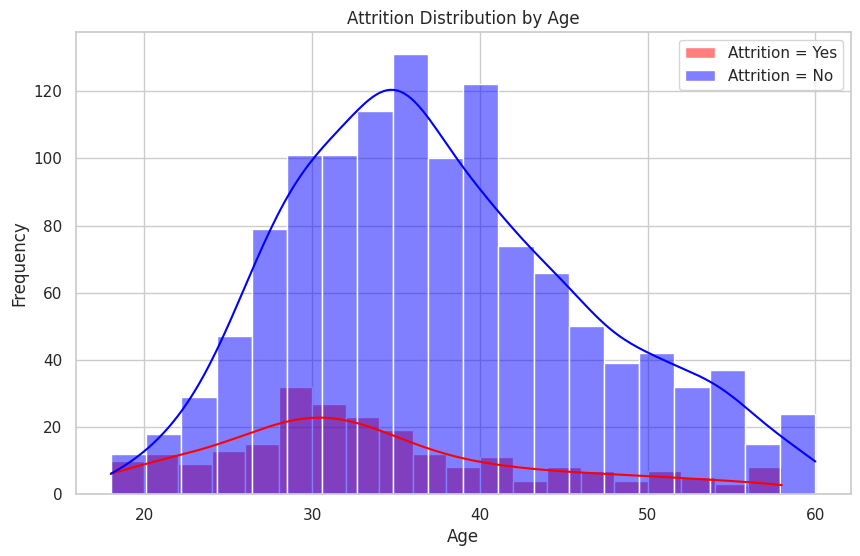

In [66]:
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(data[data['Attrition'] == 'Yes']['Age'], bins=20, kde=True, color='red', label='Attrition = Yes')
sns.histplot(data[data['Attrition'] == 'No']['Age'], bins=20, kde=True, color='blue', label='Attrition = No')
plt.title('Attrition Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

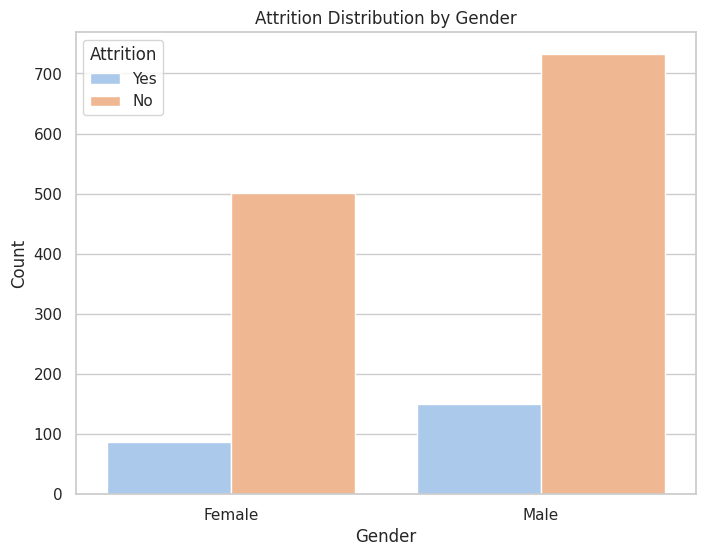

In [67]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', hue='Attrition', data=data, palette='pastel')
plt.title('Attrition Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

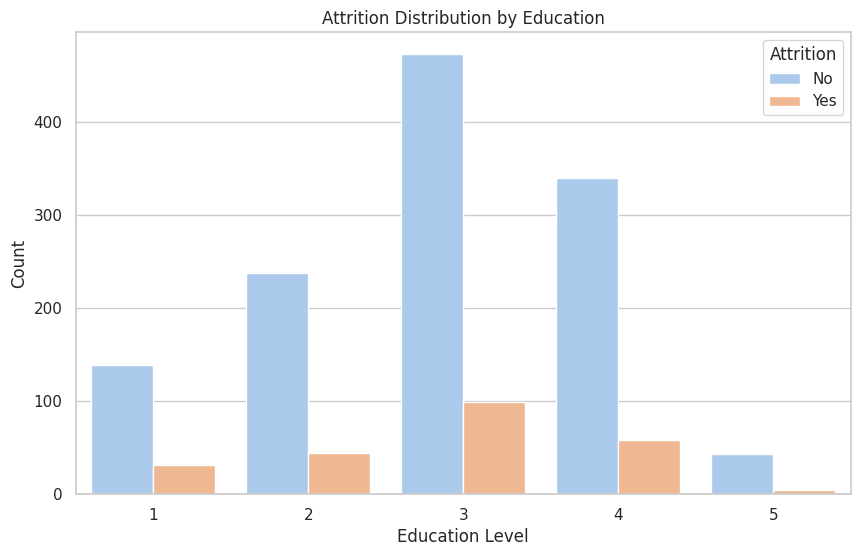

In [68]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Education', hue='Attrition', data=data, palette='pastel')
plt.title('Attrition Distribution by Education')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

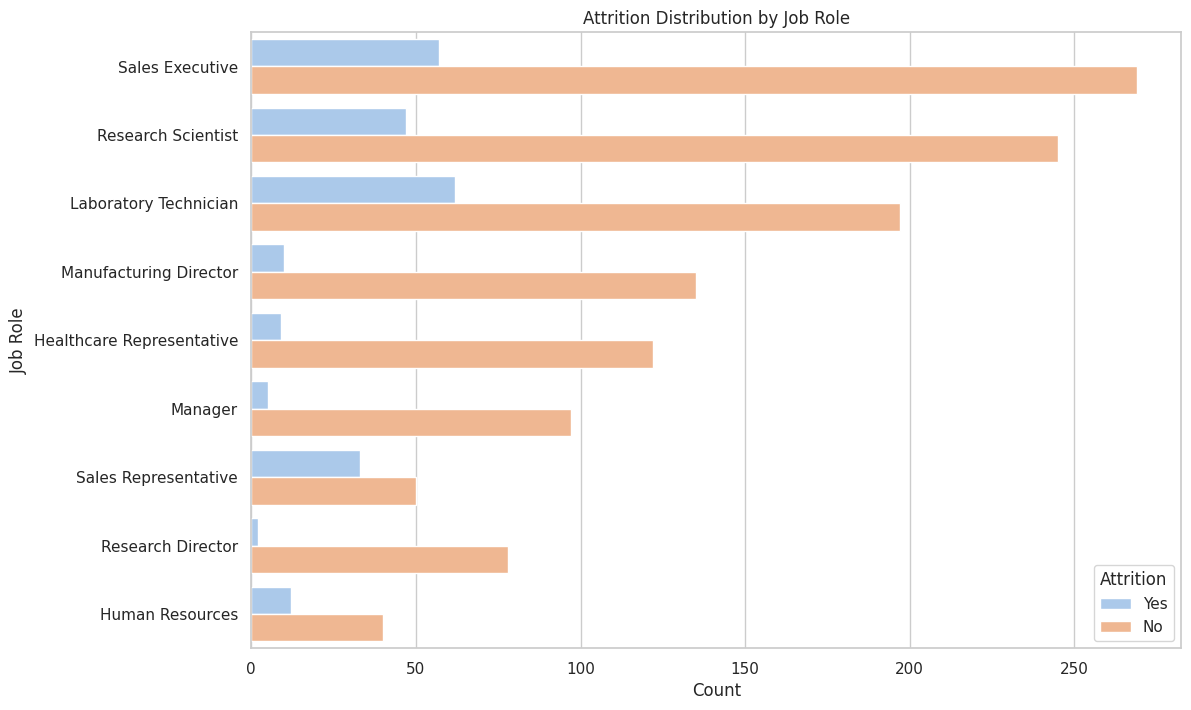

In [69]:
plt.figure(figsize=(12, 8))
sns.countplot(y='JobRole', hue='Attrition', data=data, palette='pastel')
plt.title('Attrition Distribution by Job Role')
plt.xlabel('Count')
plt.ylabel('Job Role')
plt.show()

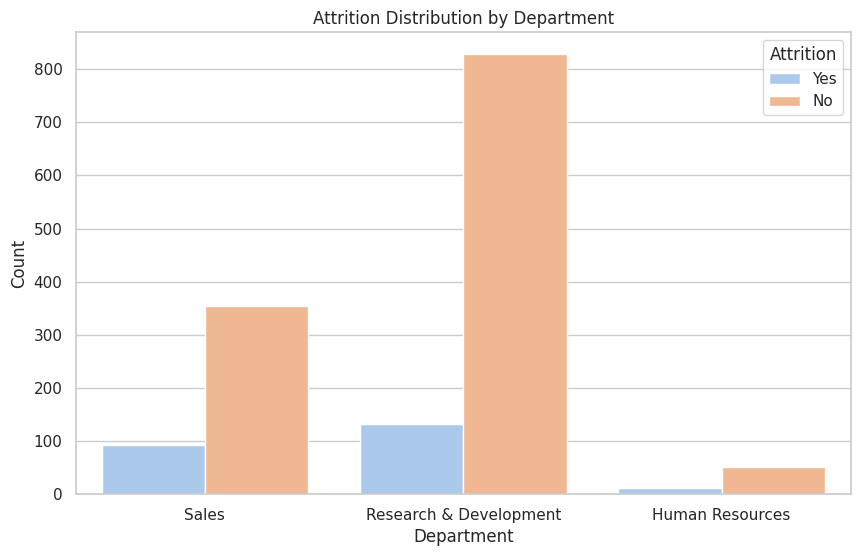

In [70]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', hue='Attrition', data=data, palette='pastel')
plt.title('Attrition Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

Correlation Matrix of Satisfaction and Work-Life Balance with Attrition

          JobSatisfaction                                               \
                    count      mean       std  min  25%  50%  75%  max   
Attrition                                                                
No                 1233.0  2.778589  1.093277  1.0  2.0  3.0  4.0  4.0   
Yes                 237.0  2.468354  1.118058  1.0  1.0  3.0  3.0  4.0   

          EnvironmentSatisfaction            ...           WorkLifeBalance  \
                            count      mean  ...  75%  max           count   
Attrition                                    ...                             
No                         1233.0  2.771290  ...  4.0  4.0          1233.0   
Yes                         237.0  2.464135  ...  4.0  4.0           237.0   

                                                        
               mean       std  min  25%  50%  75%  max  
Attrition                                               
No         2.781022  0.681907  1.0  2.0  3.0  3.0  4.0  
Yes       

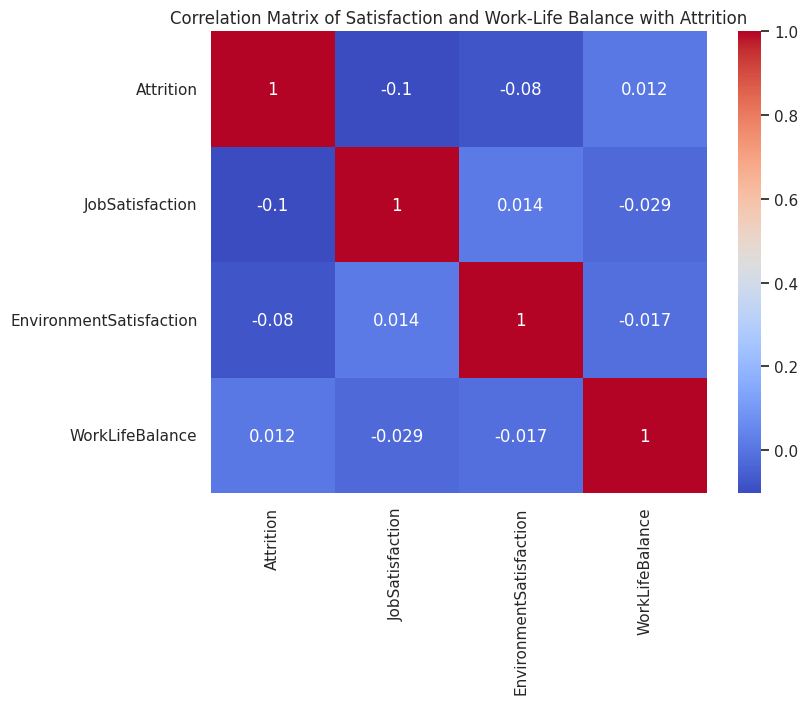

In [71]:
summary_stats = data .groupby('Attrition')[['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance']].describe()
print(summary_stats)

correlation_matrix = data [['Attrition', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance']].apply(lambda x: pd.factorize(x)[0]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Satisfaction and Work-Life Balance with Attrition')
plt.show()

The correlation matrix reveals that JobSatisfaction has the strongest negative correlation with Attrition, suggesting that it's the most influential factor in predicting employee turnover. EnvironmentSatisfaction and WorkLifeBalance also have some influence, but to a lesser extent.

In [72]:
# Encoding categorical variables
print(data["JobRole"].unique())
print(data["MaritalStatus"].unique())
print(data["OverTime"].unique())

['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
['Single' 'Married' 'Divorced']
['Yes' 'No']


In [87]:
label_encoder = LabelEncoder()
data['OverTime_encoded'] = label_encoder.fit_transform(data['OverTime'])
data_encoded = pd.get_dummies(data, columns=['JobRole', 'MaritalStatus','BusinessTravel'], drop_first=True)
data_encoded.drop('OverTime', axis=1, inplace=True)
print(data_encoded.head())

   Age Attrition  DailyRate              Department  DistanceFromHome  \
0   41       Yes       1102                   Sales                 1   
1   49        No        279  Research & Development                 8   
2   37       Yes       1373  Research & Development                 2   
3   33        No       1392  Research & Development                 3   
4   27        No        591  Research & Development                 2   

   Education EducationField  EmployeeCount  EmployeeNumber  \
0          2  Life Sciences              1               1   
1          1  Life Sciences              1               2   
2          2          Other              1               4   
3          4  Life Sciences              1               5   
4          1        Medical              1               7   

   EnvironmentSatisfaction  ... JobRole_Manager  \
0                        2  ...           False   
1                        3  ...           False   
2                        4  ...    

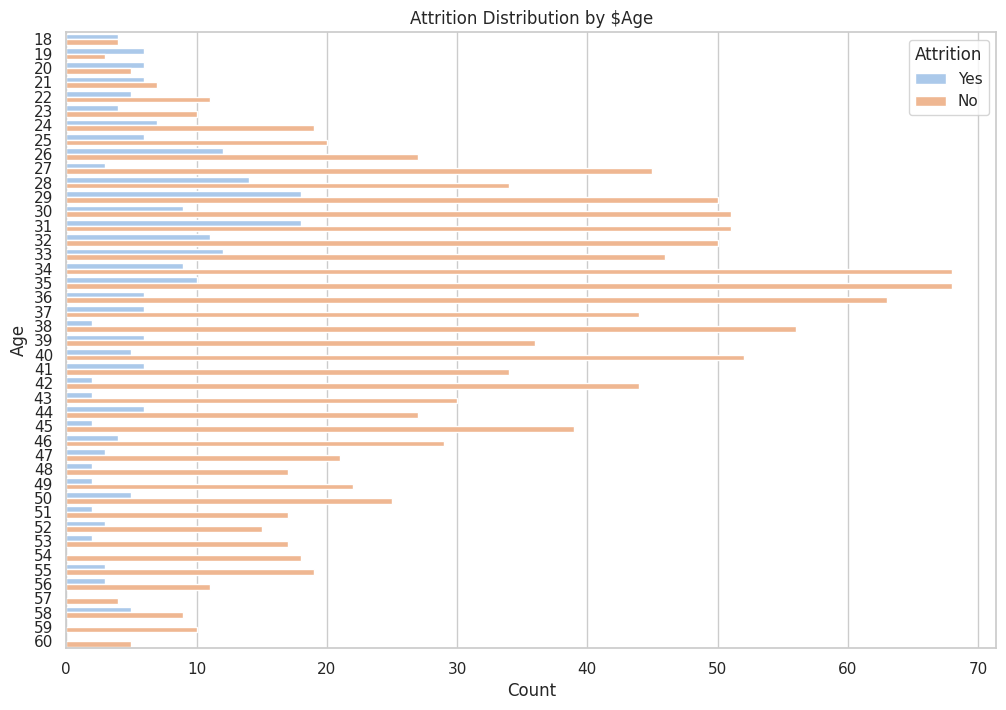

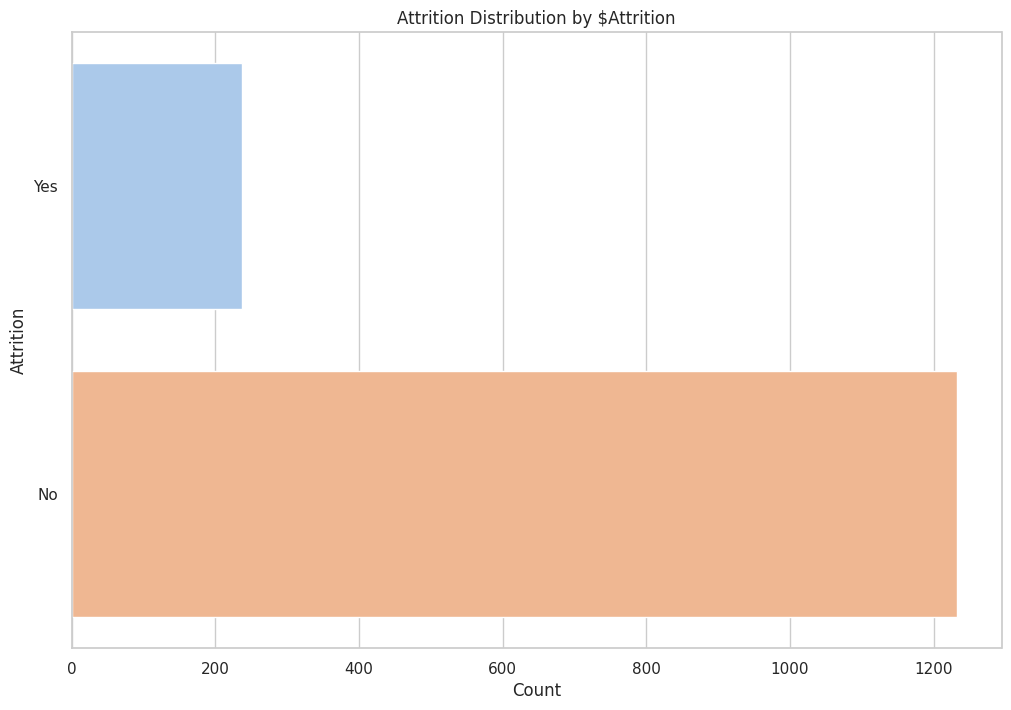

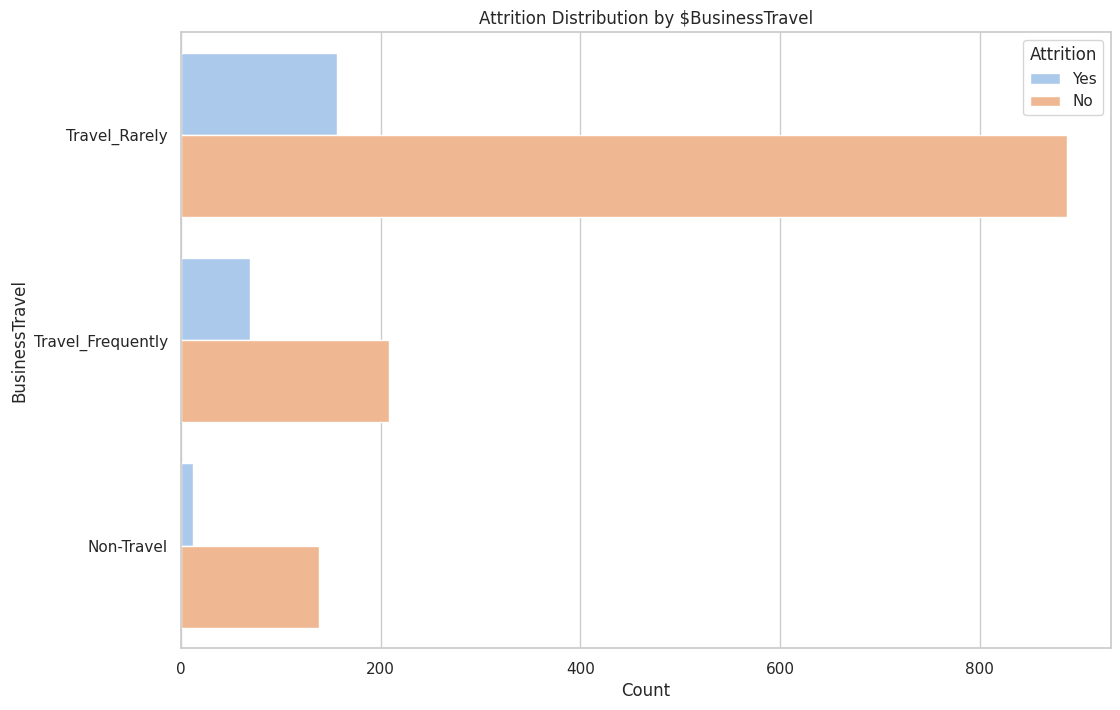

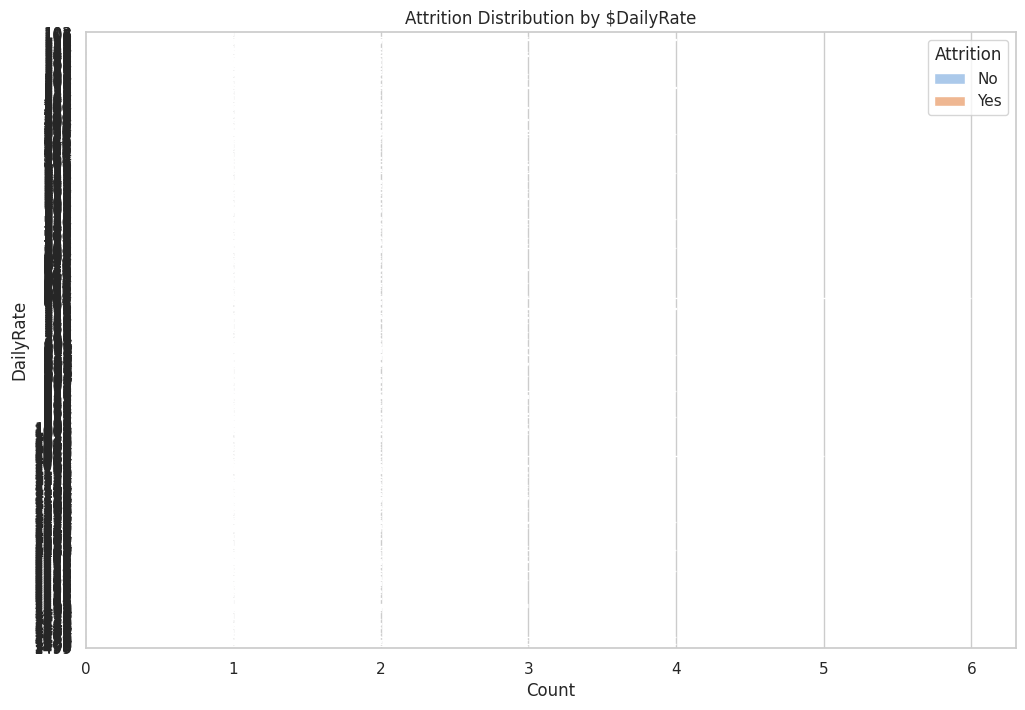

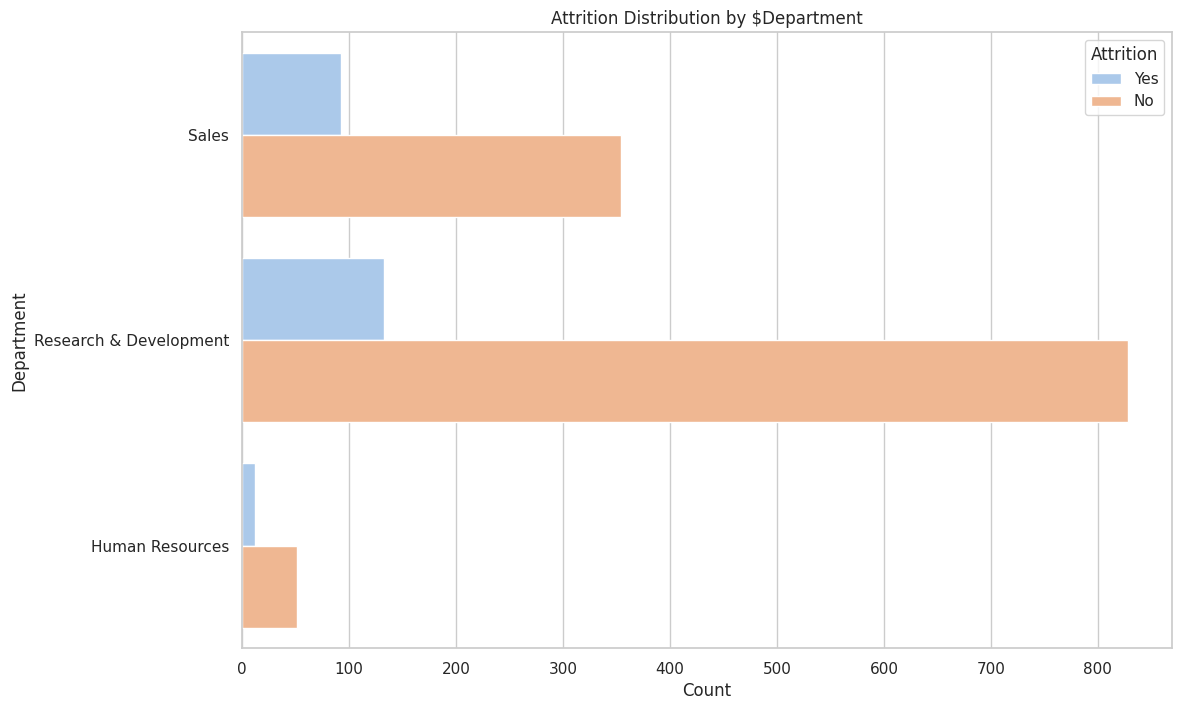

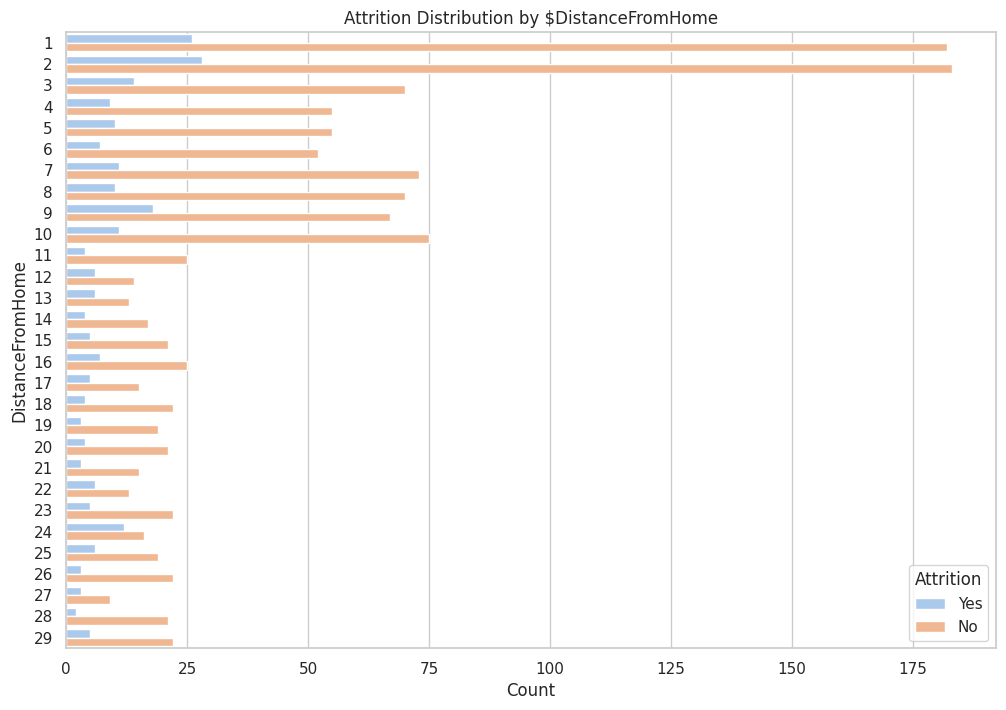

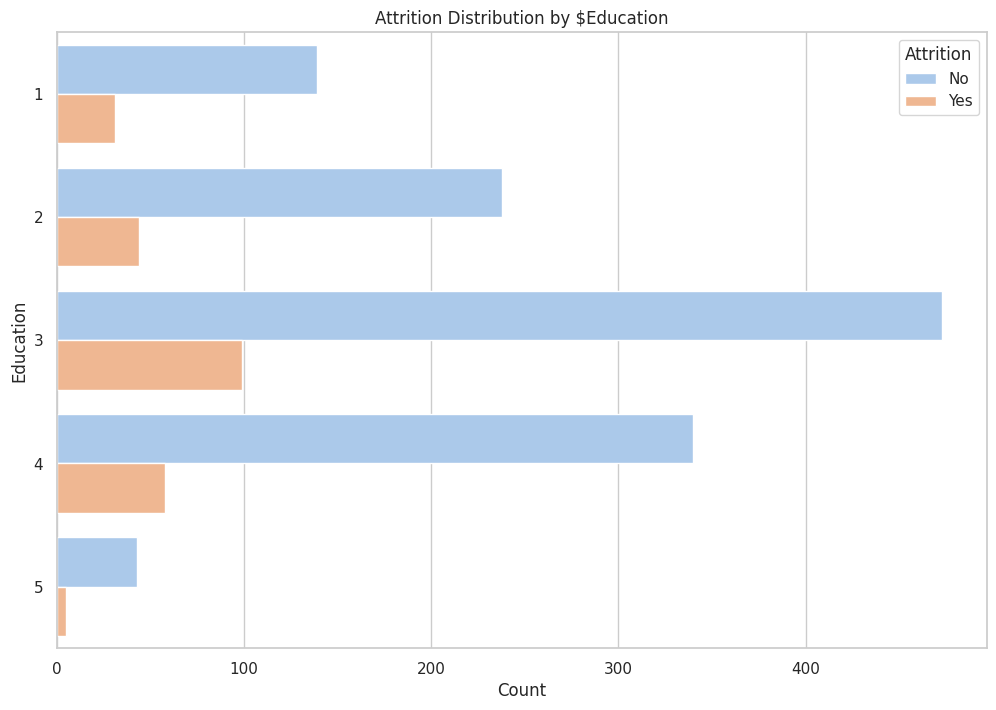

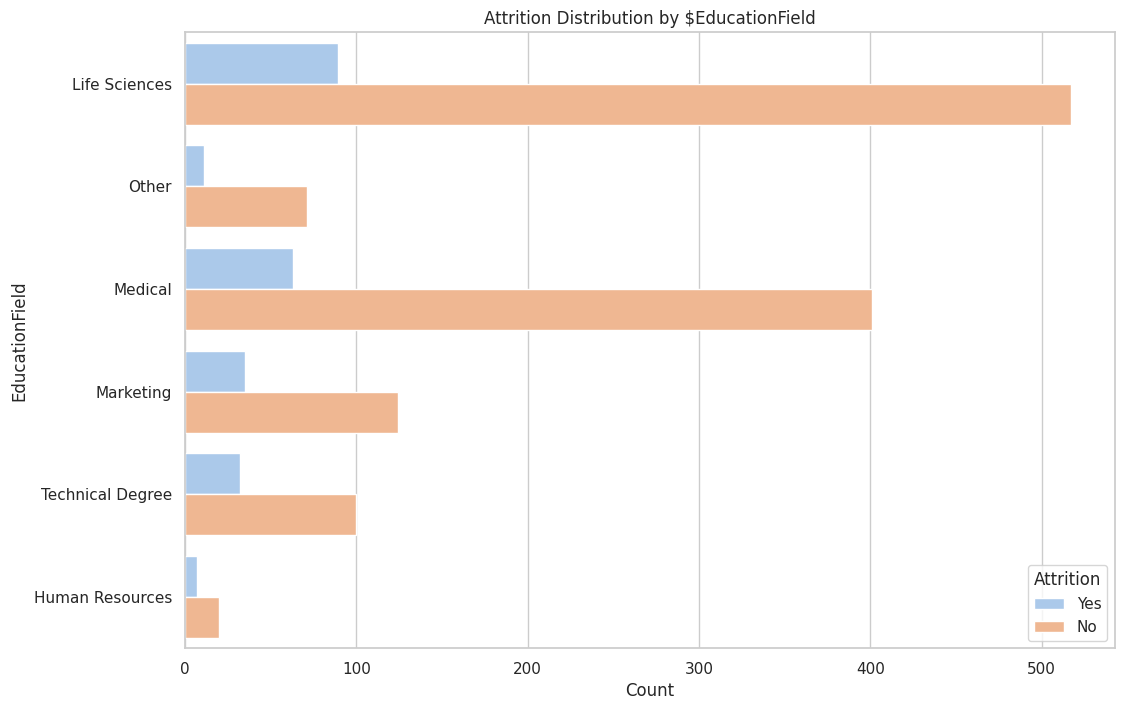

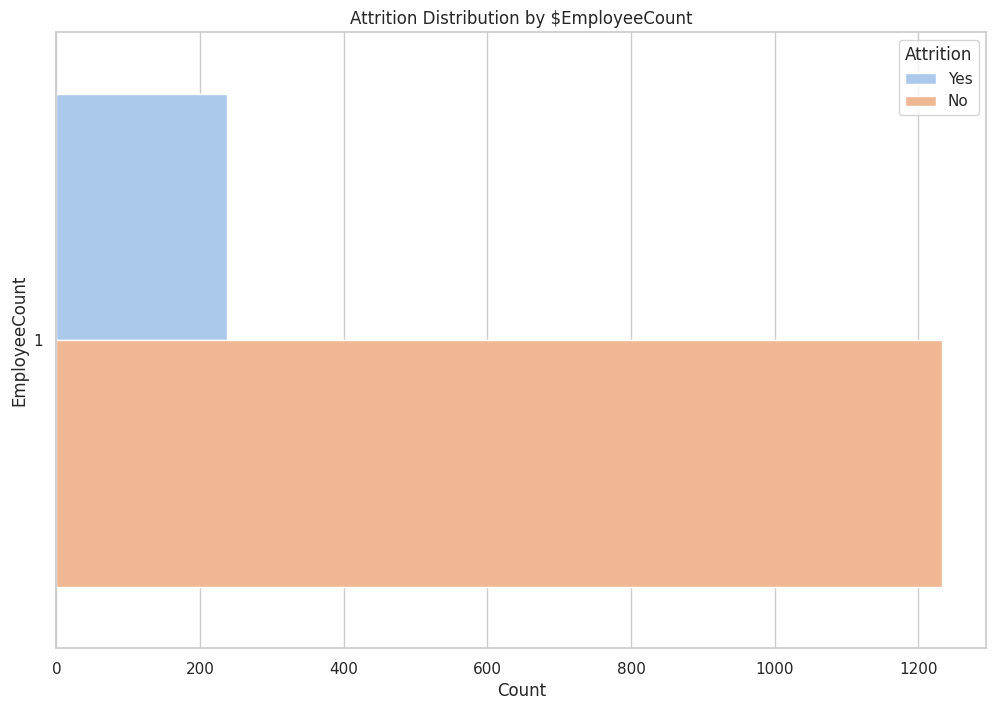

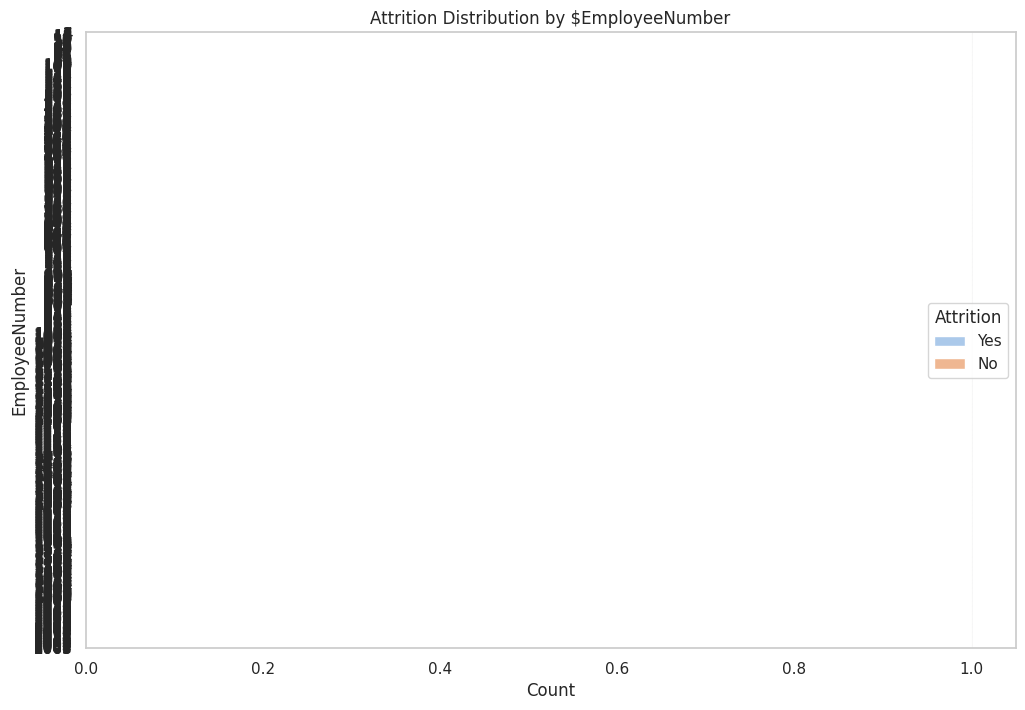

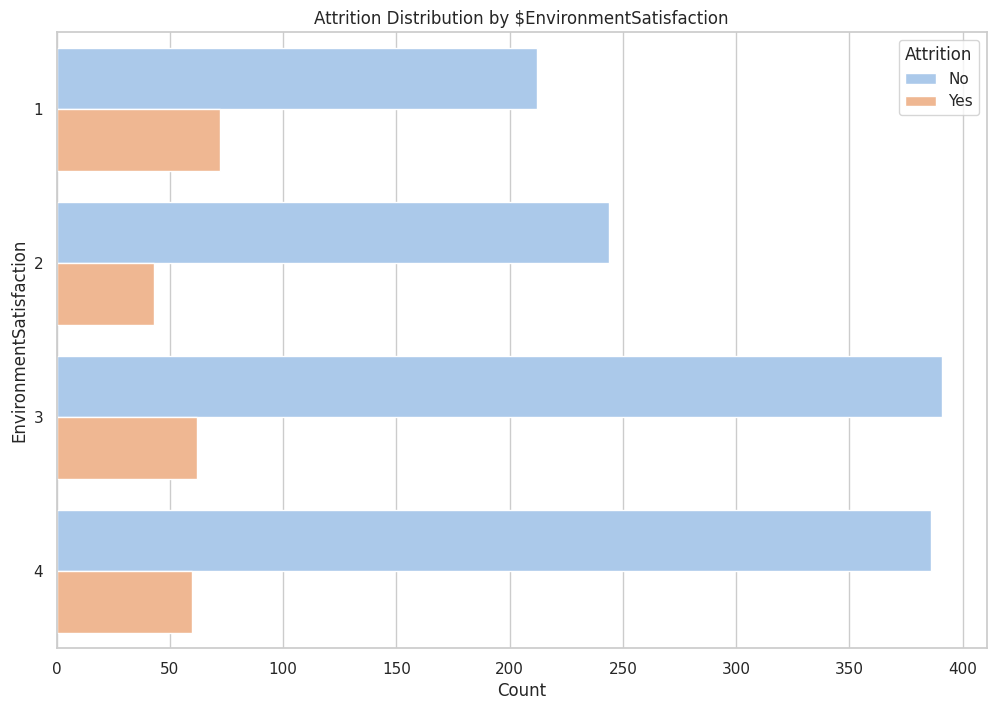

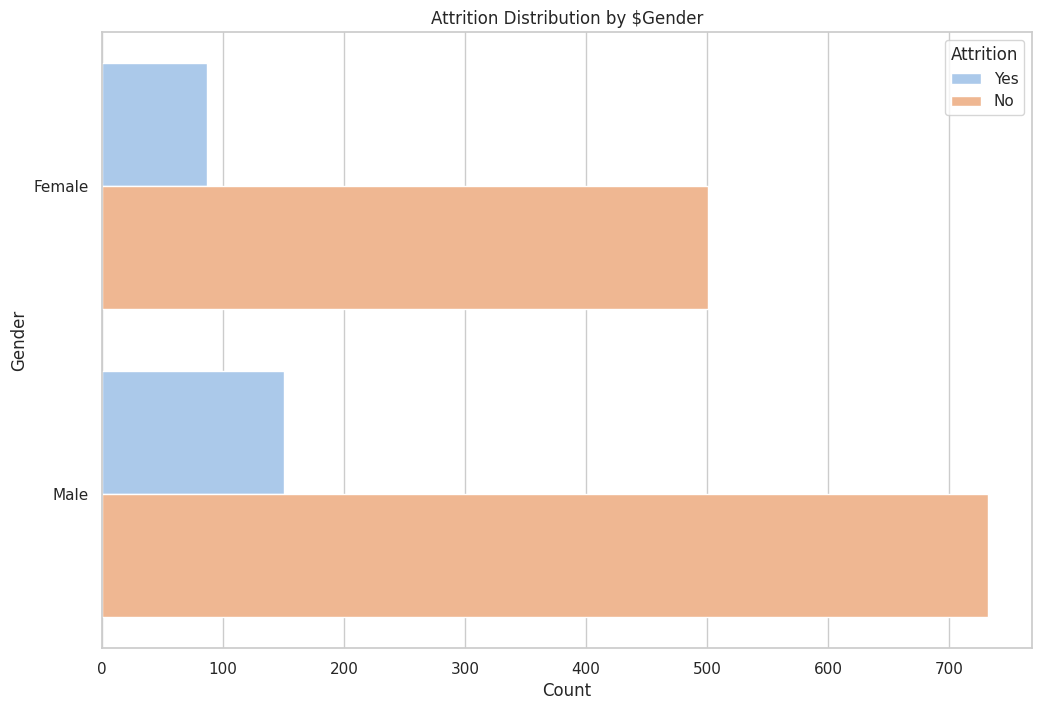

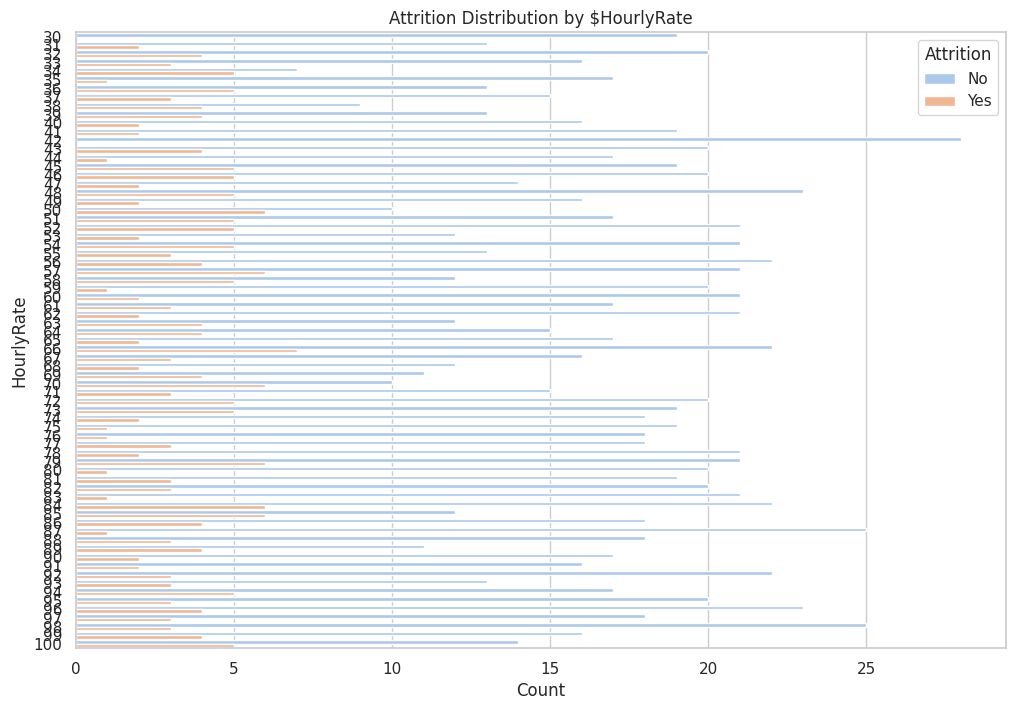

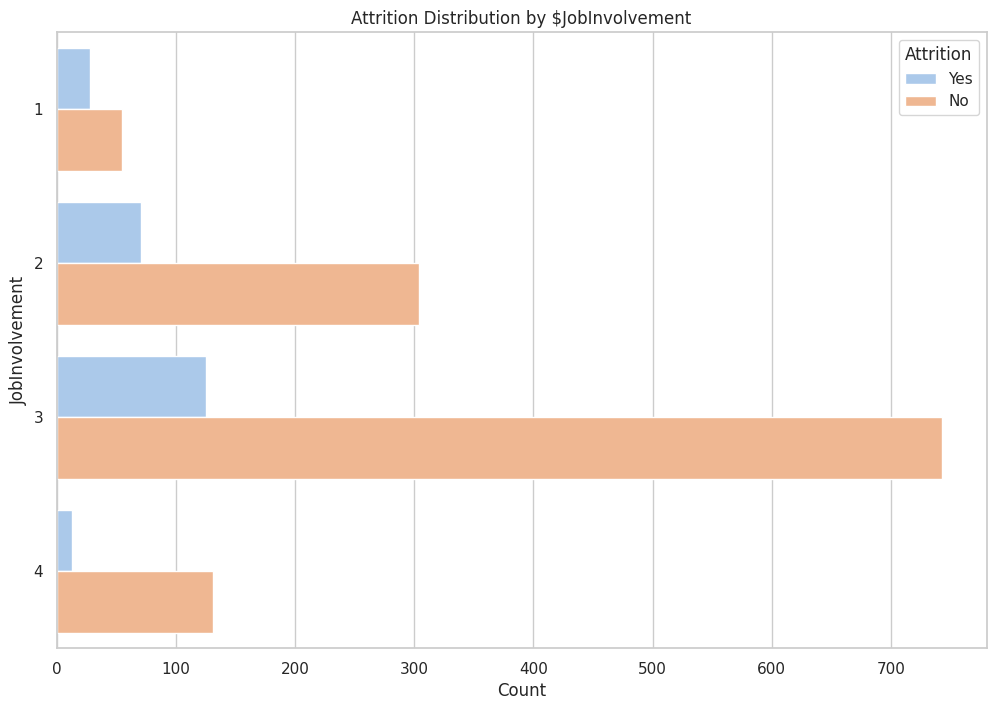

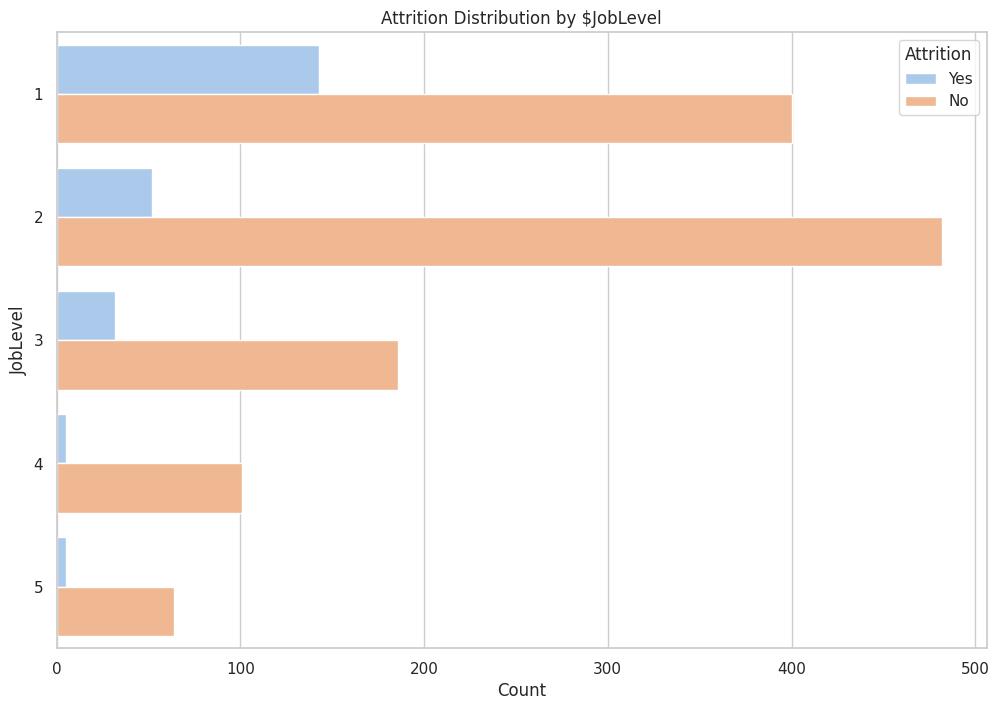

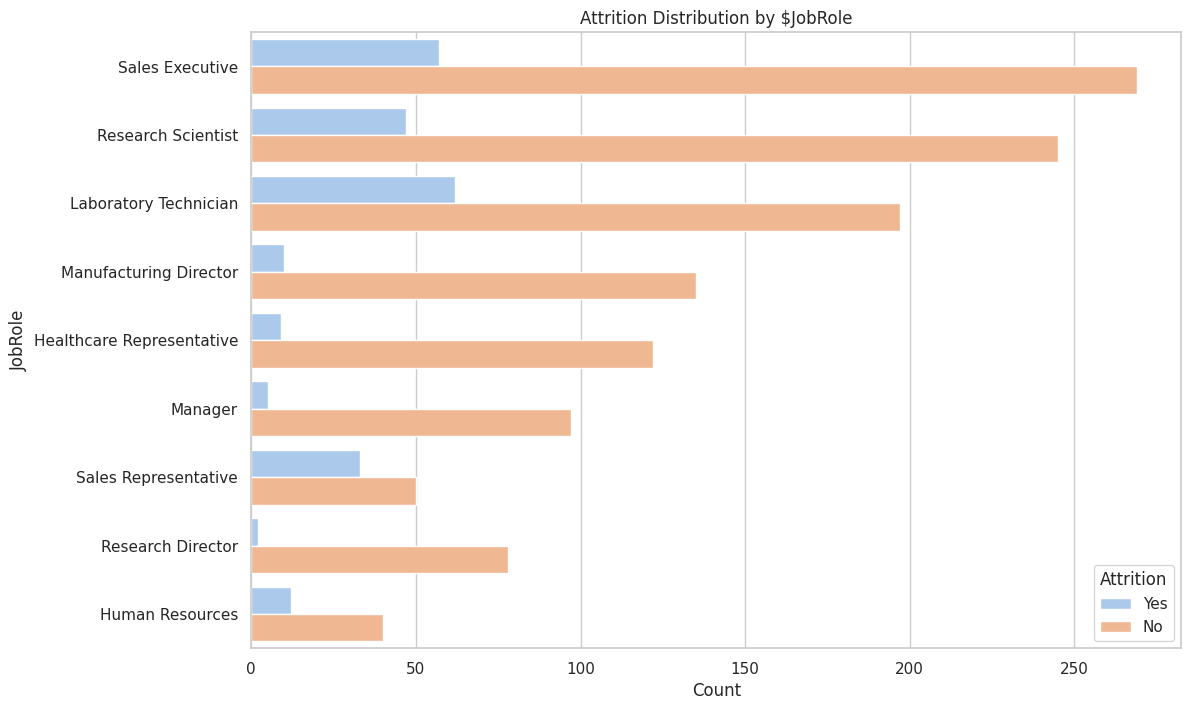

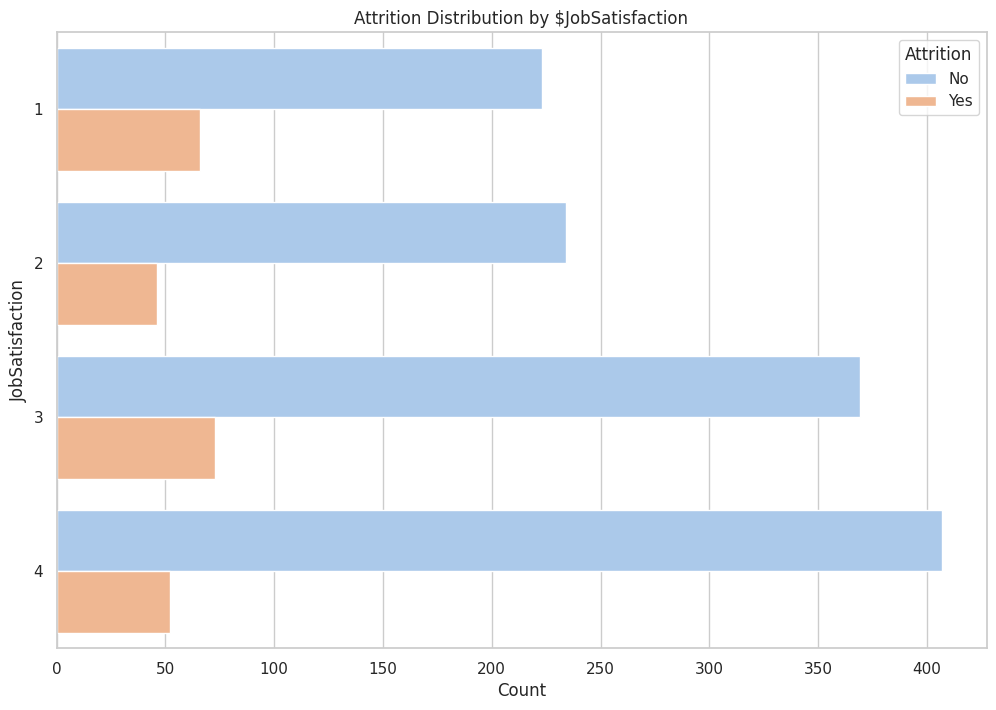

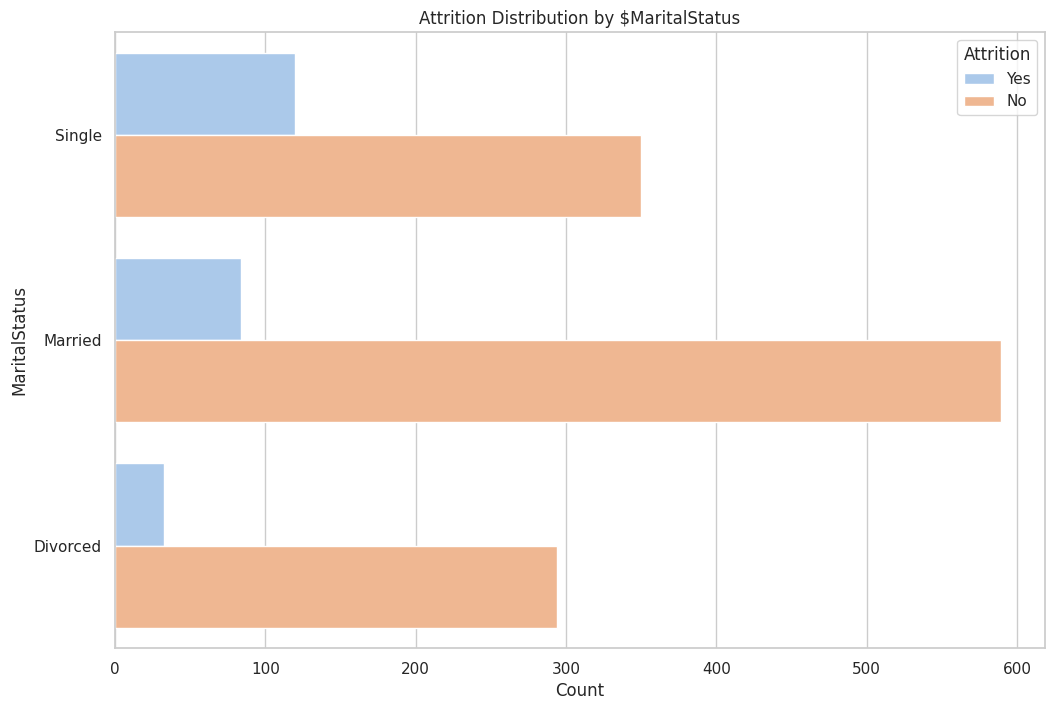

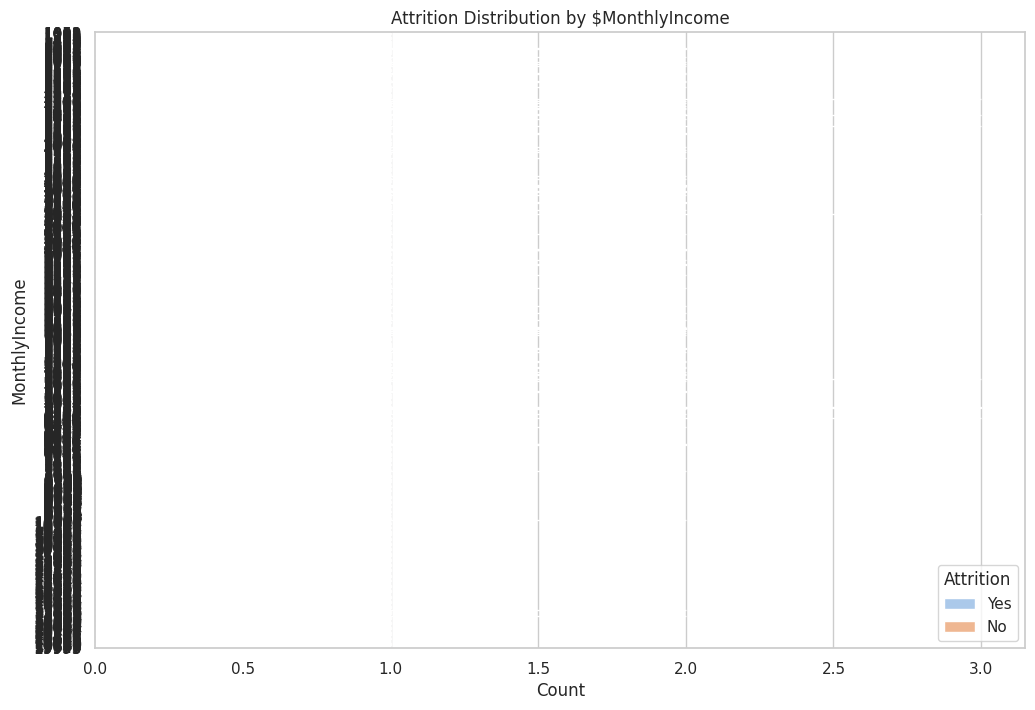

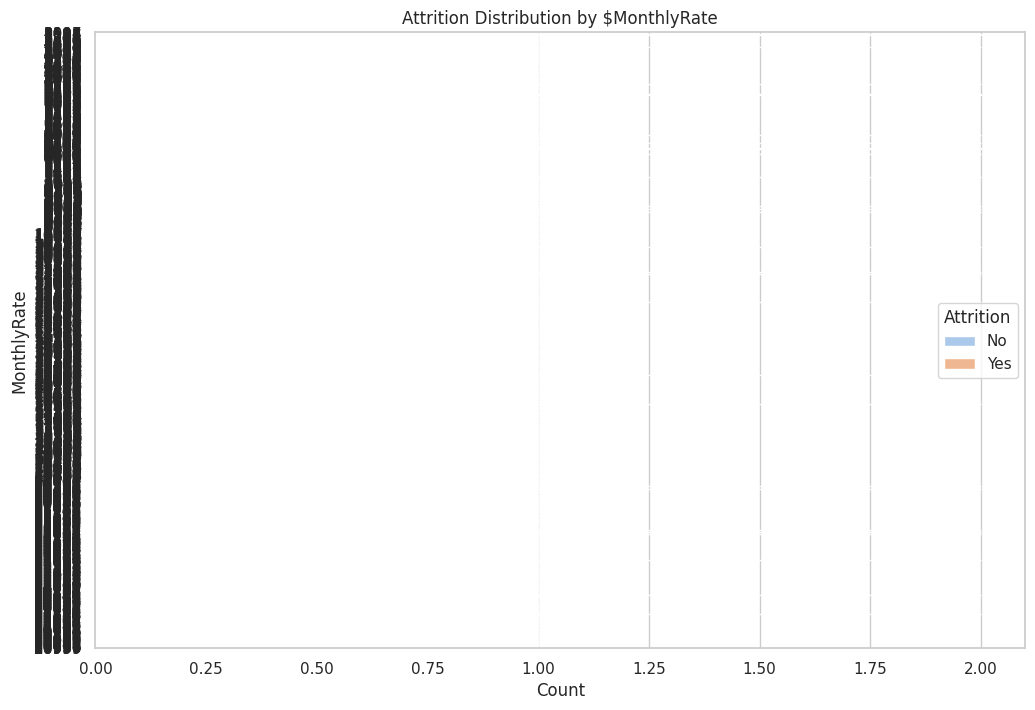

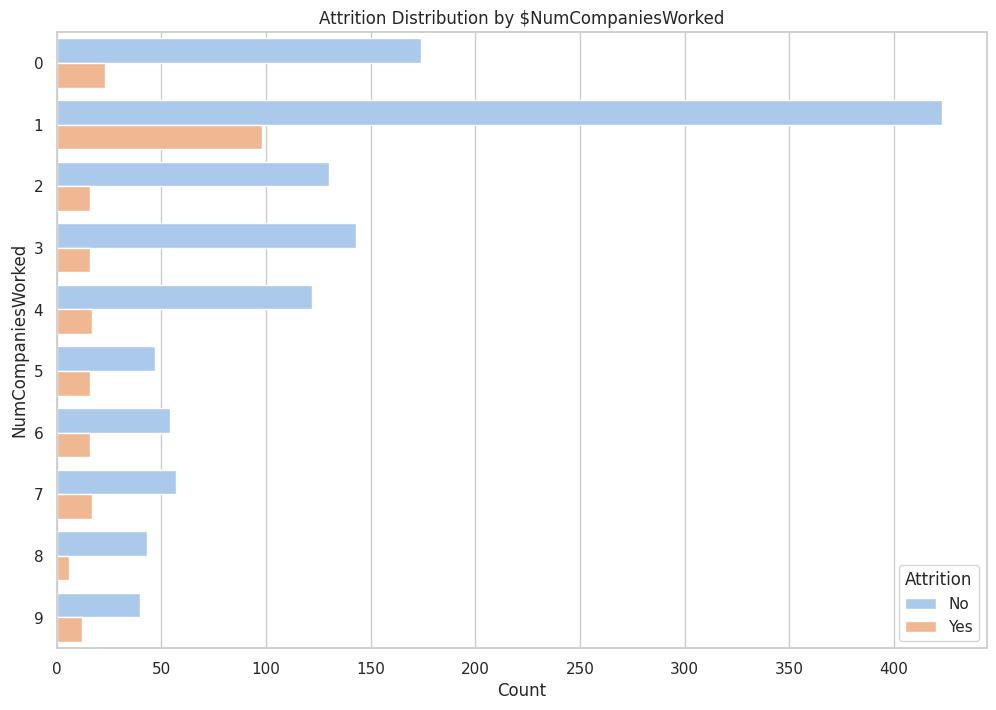

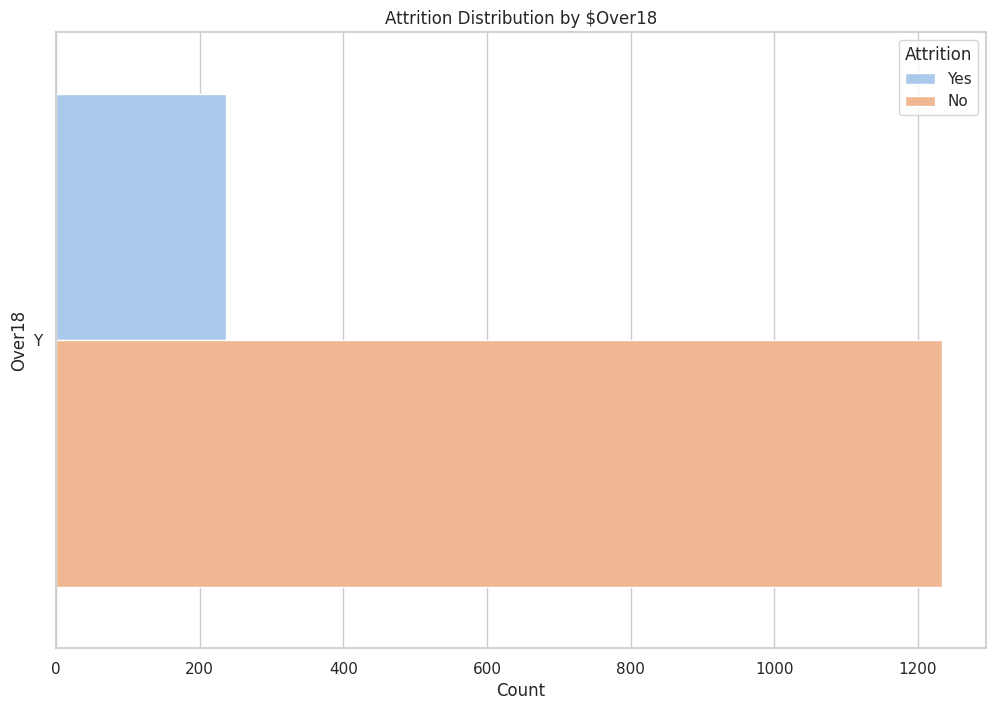

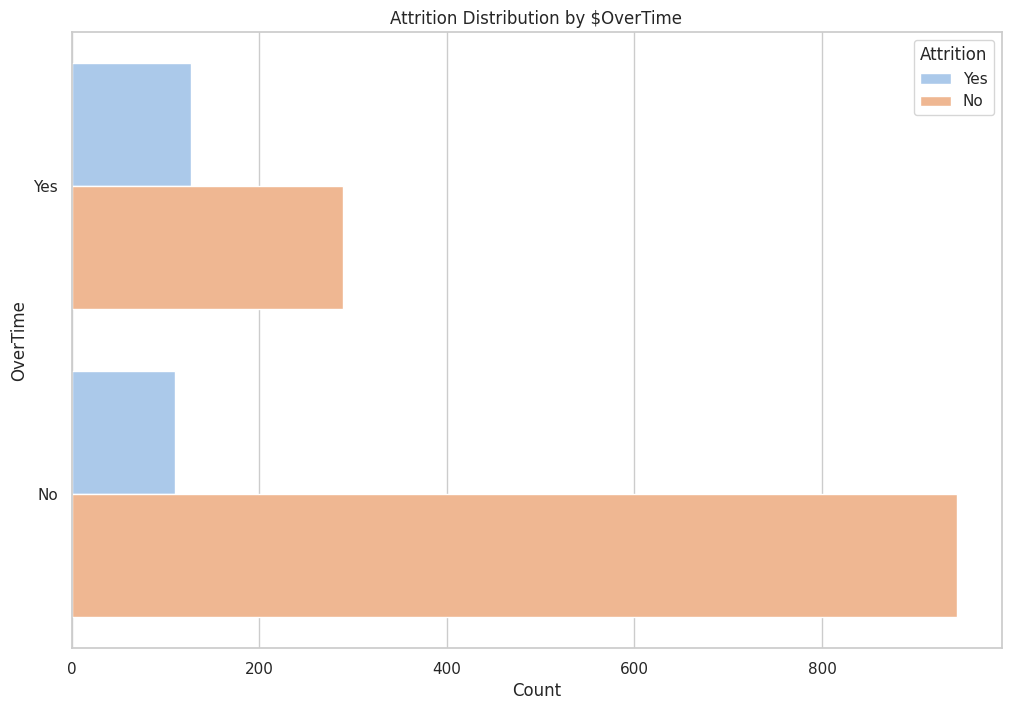

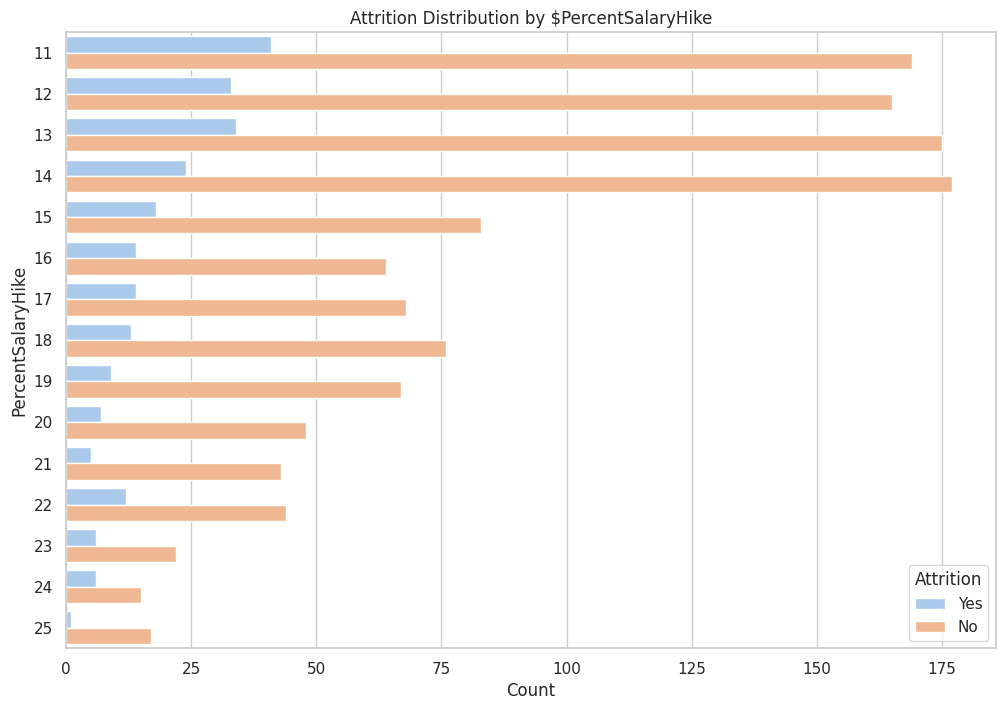

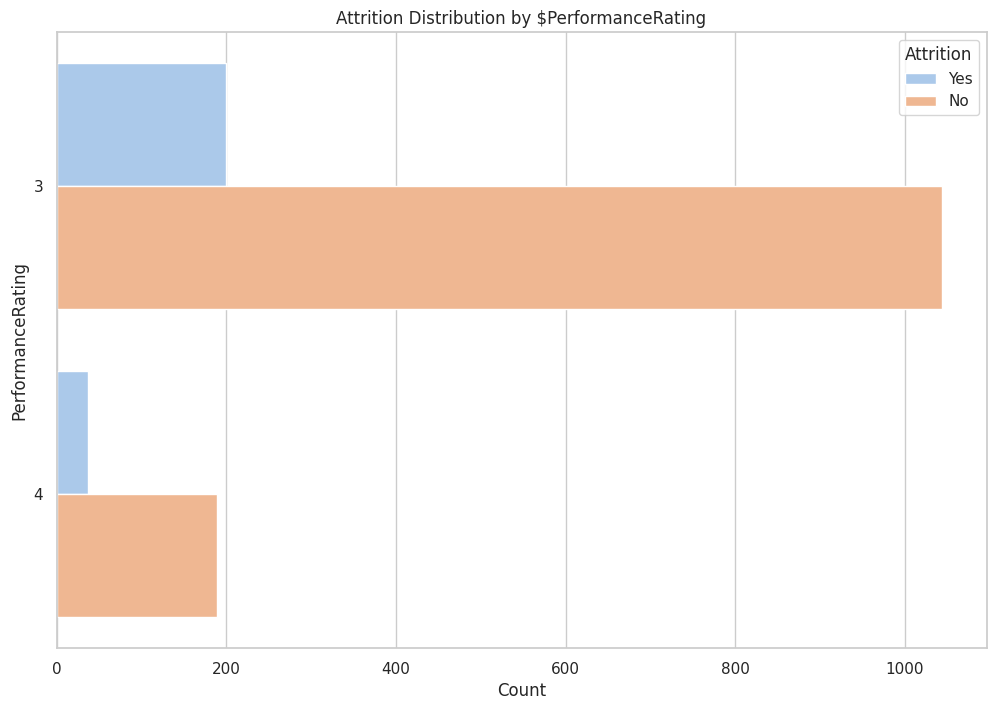

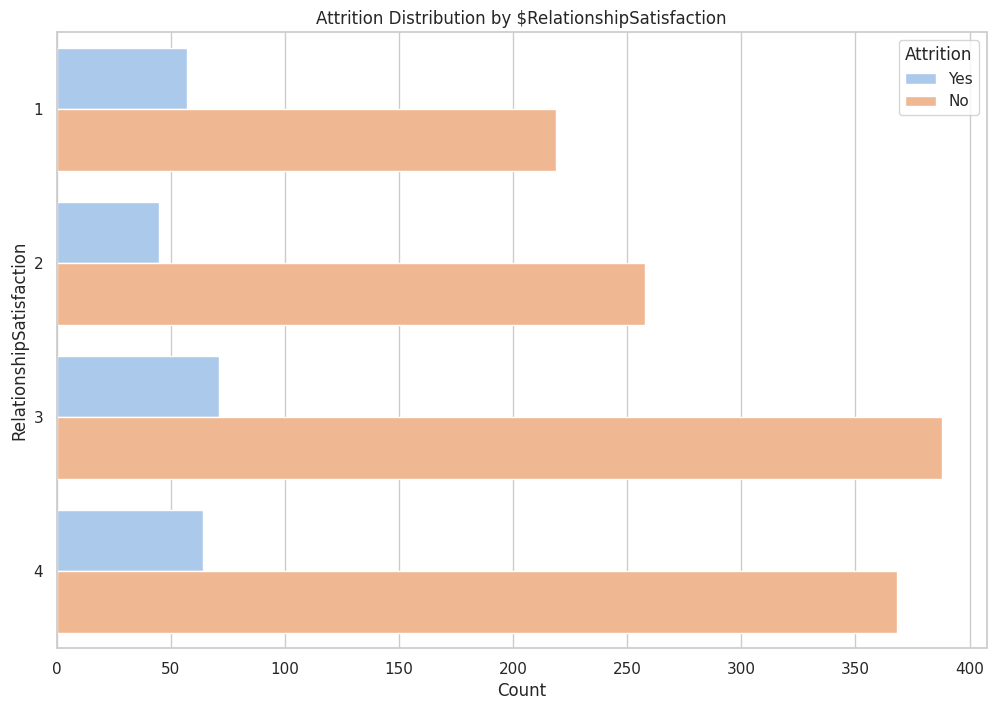

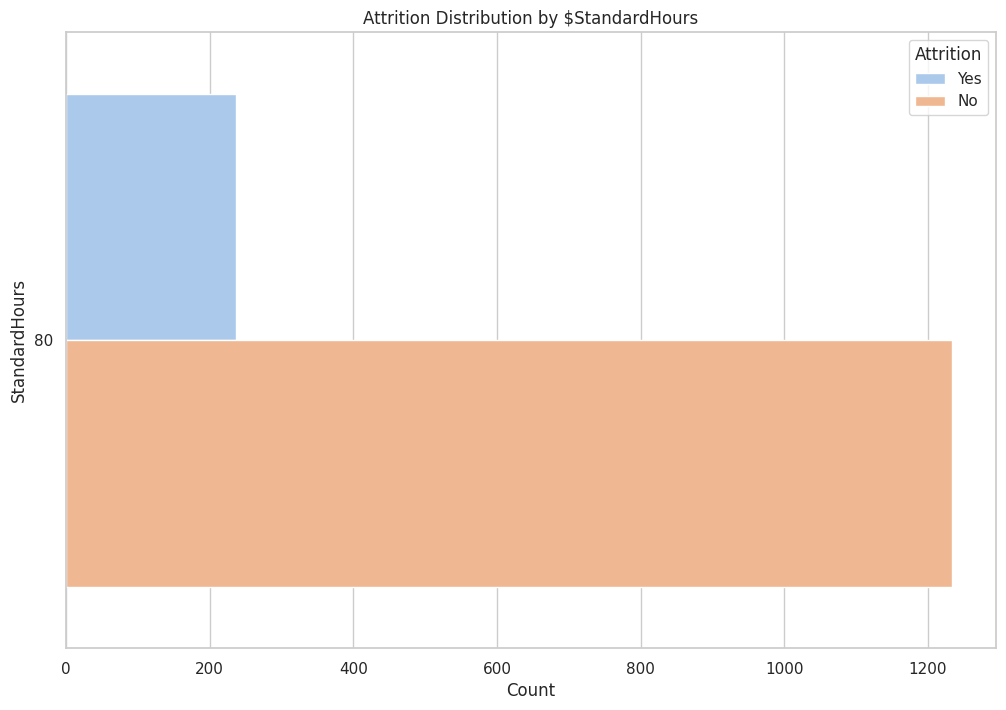

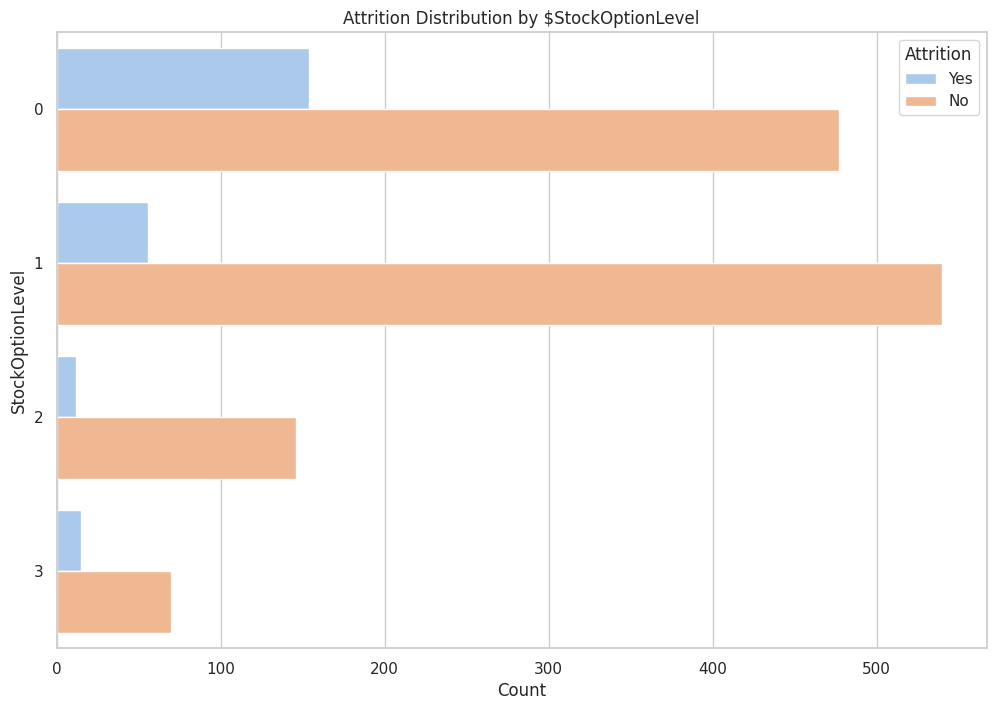

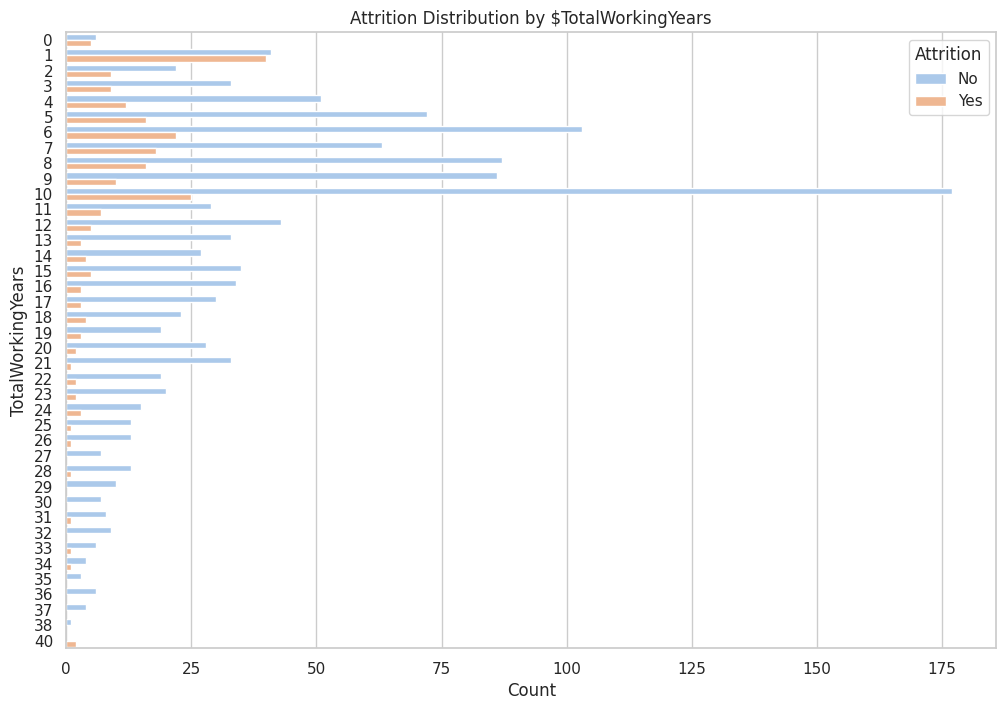

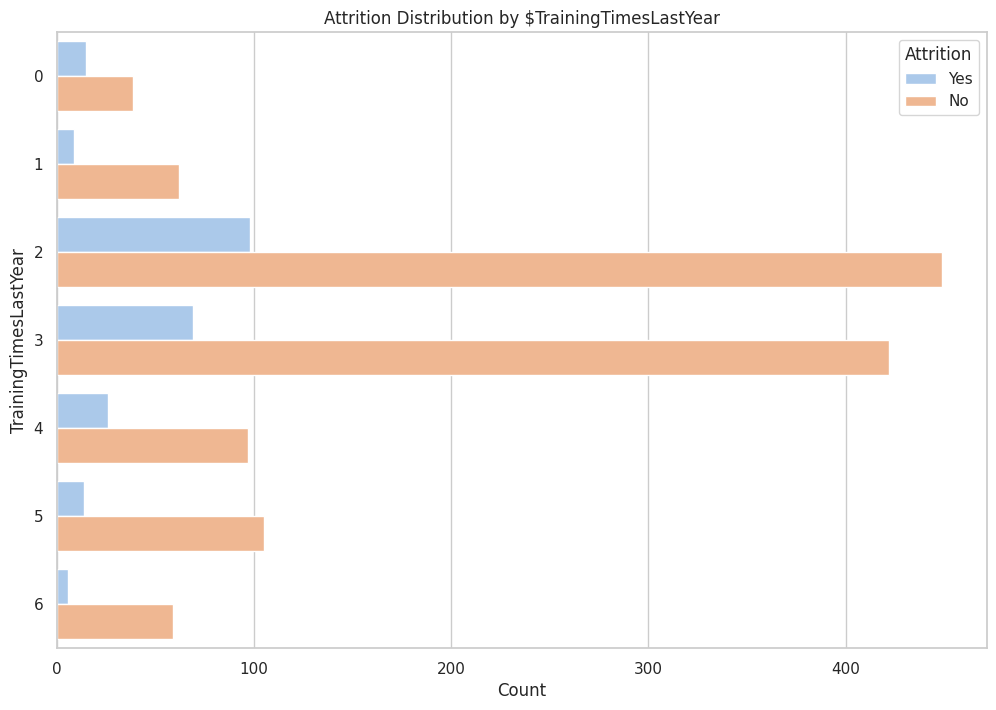

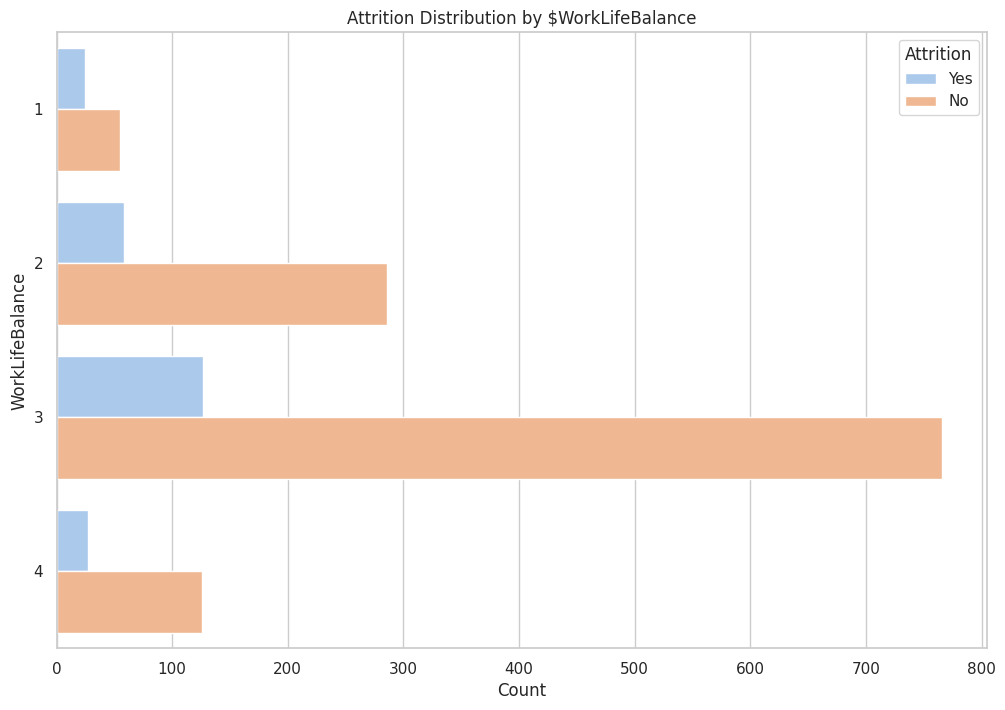

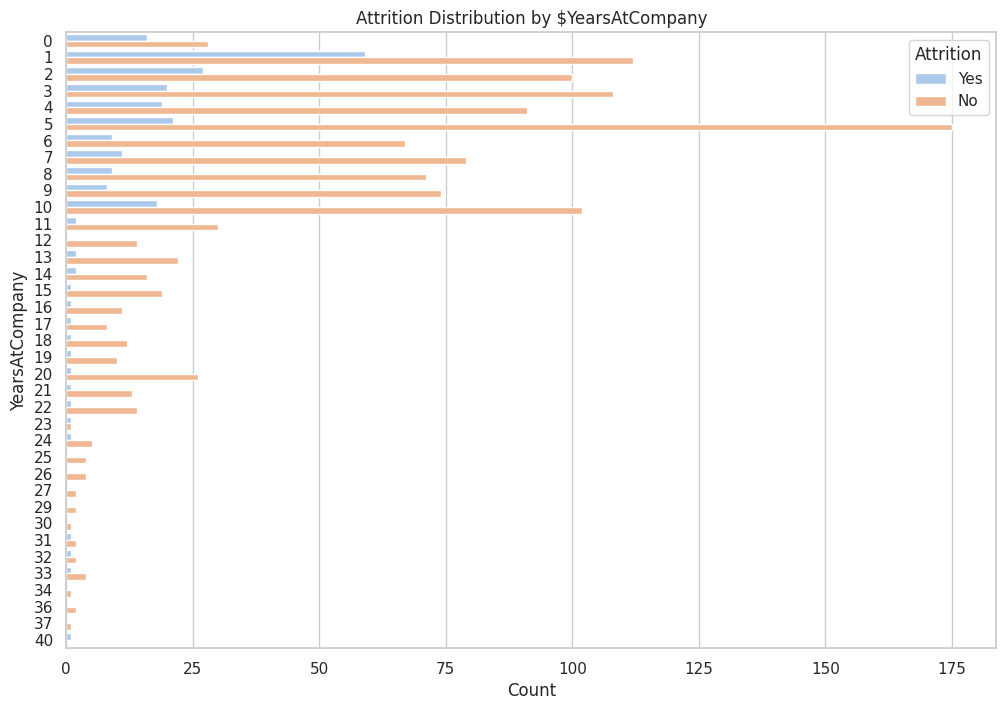

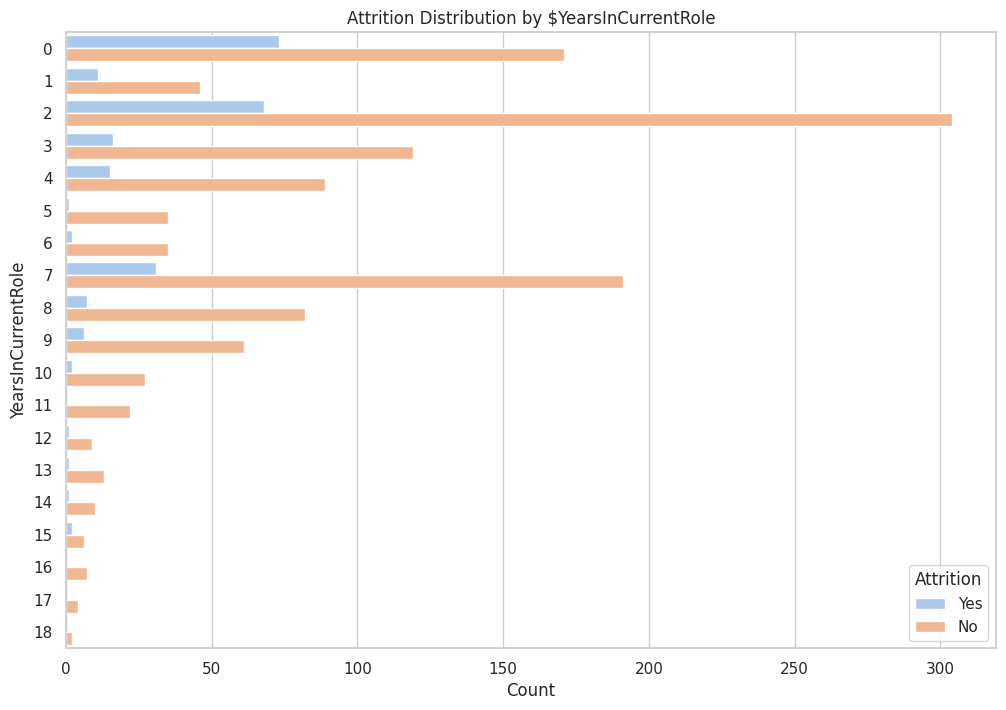

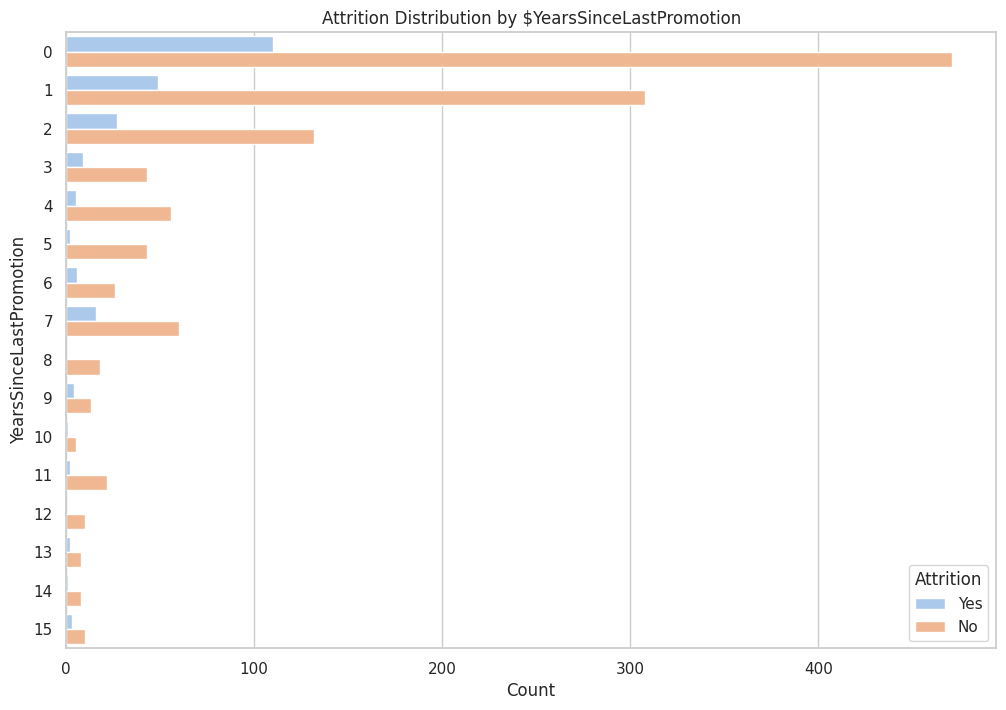

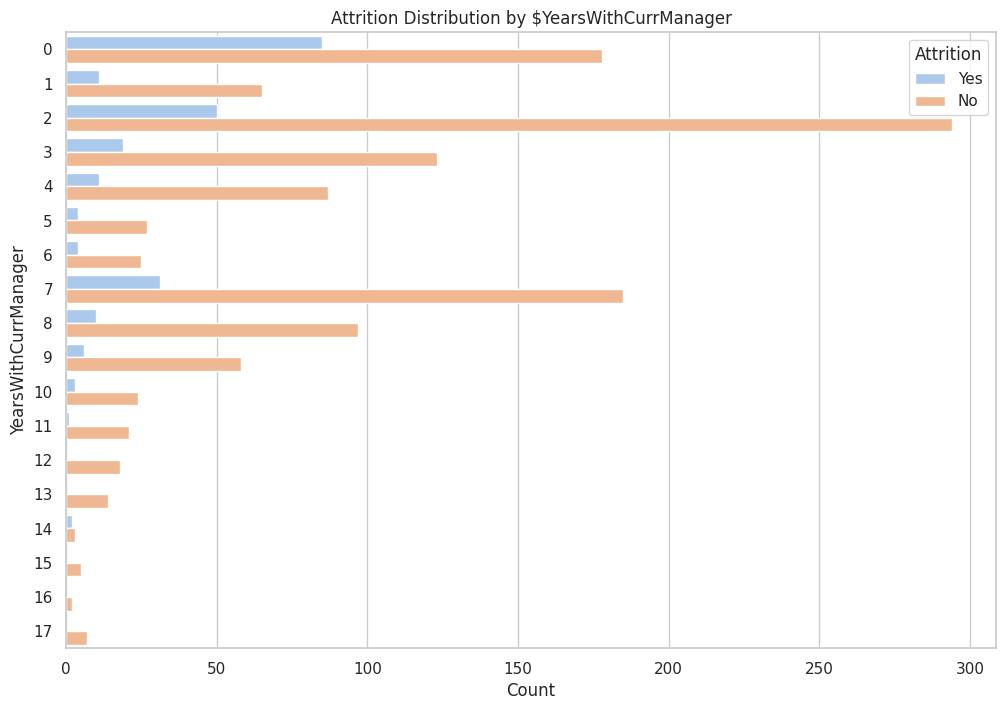

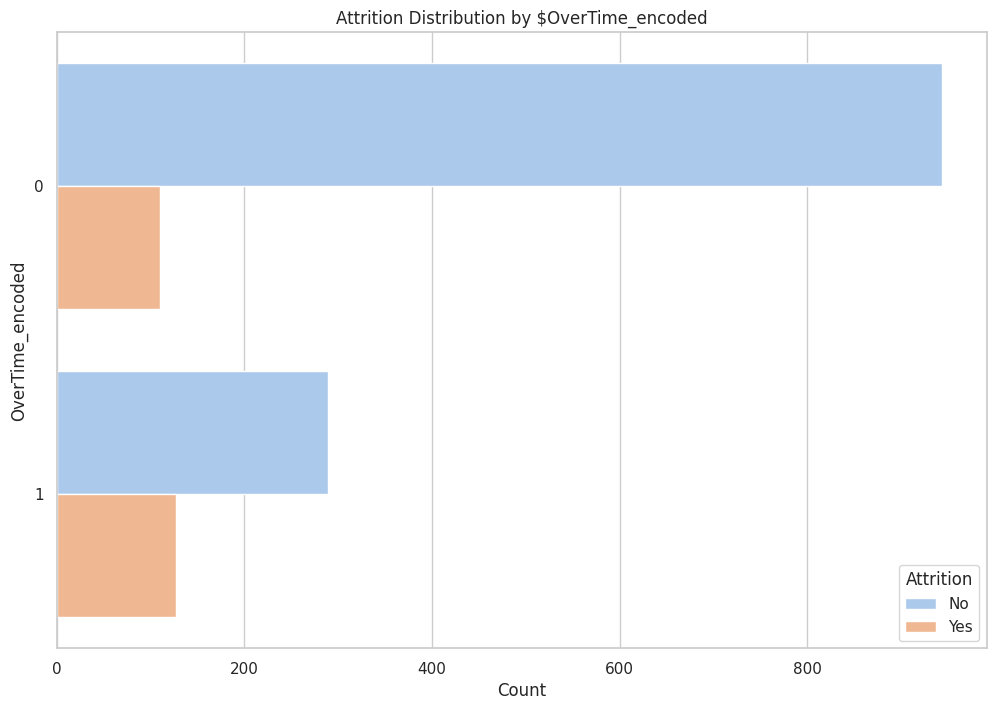

In [76]:
for i in data.columns:
  plt.figure(figsize=(12, 8))
  sns.countplot(y=i, hue='Attrition', data=data, palette='pastel')
  plt.title(f'Attrition Distribution by {i}')
  plt.xlabel('Count')
  plt.ylabel(i)
  plt.show()

In [78]:
from sklearn.preprocessing import StandardScaler

cols_to_standardize = ['Age', 'DistanceFromHome', 'DailyRate',
                       'TotalWorkingYears', 'YearsAtCompany',
                       'YearsInCurrentRole', 'YearsSinceLastPromotion',
                       'YearsWithCurrManager']

scaler = StandardScaler()
data_standardized = data.copy()
data_standardized[cols_to_standardize] = scaler.fit_transform(data[cols_to_standardize])

print(data_standardized.head())

        Age Attrition     BusinessTravel  DailyRate              Department  \
0  0.446350       Yes      Travel_Rarely   0.742527                   Sales   
1  1.322365        No  Travel_Frequently  -1.297775  Research & Development   
2  0.008343       Yes      Travel_Rarely   1.414363  Research & Development   
3 -0.429664        No  Travel_Frequently   1.461466  Research & Development   
4 -1.086676        No      Travel_Rarely  -0.524295  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0         -1.010909          2  Life Sciences              1               1   
1         -0.147150          1  Life Sciences              1               2   
2         -0.887515          2          Other              1               4   
3         -0.764121          4  Life Sciences              1               5   
4         -0.887515          1        Medical              1               7   

   ...  StandardHours StockOptionLevel  Tota